###  Berm Condition & Vegetation Analysis


Loads `../data/merged.csv` produced by the data-prep notebook  
(`berm data processing - condition vegetation.ipynb`).


**Research questions**

1. What is predictive of berm condition / intactness? 
2. What is predictive of berm impact on surrounding vegetation, 
3. What is the correspondence between these condition and vegetation response, if any?

Methods: 
- Variables are highly correlated, we first examined which variables explain highest fraction variance in SAVI 



Results:
  - Longer berms more likely to be degraded. Perhaps because more failure points 


Landform is not the best predictor, but useful as a conceptual framework – correspondence to berm purpose (are some water spreader berms actually flood control berms in the dataset).
For managemen 

-  Fan terraces are more effective because steeper,  possibly because steeper (more runoff capture), possibly lower clay and no B horizon?

-  Floodplains less effective because gentle slopes,  possibly high clay

Different reasons, design criteria, inherent differnces.

Flow accumulation tends to be higher in floodplains --> intact berms tend to have lower flow accumulation

---

**Reference**


Nichols, M. H., Duke, S. E., Holifield Collins, C., & Thompson, L. (2023). Legacy earthen berms influence vegetation and hydrologic complexity in the Altar Valley, Arizona. *International Soil and Water Conservation Research*. https://doi.org/10.1016/j.iswcr.2023.01.005


In [62]:
import glob
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module=r'seaborn(\..*)?')
from IPython.display import display, HTML
import re
pd.set_option('display.max_columns', 50)


In [63]:
import sys as _sys
_sys.path.insert(0, '../src')
from constants import (
    INTACT_COL, DEGRADED_COL, BREACH_COL, FLANK_COL,
    LF_COLORS, lf_order,
    LENGTH_COLORS, length_order,
    SLOPE_COLORS, slope_order,
    CLAY_COLORS, clay_order,
    SOILDEV_COLORS, soildev_order,
    TEXTURE_COLORS, texture_order,
    LBL_EFFECTIVE, LBL_INEFFECTIVE, eff_order, eff_colors,
    fail_order, fail_colors,
    MODEL_CLR_CONDITION, MODEL_CLR_VEGRESPONSE, MODEL_CLR_CHANCE,
)


In [64]:
data = pd.read_csv('../data/merged.csv')
print(f'Loaded {len(data):,} rows  |  columns: {list(data.columns)}')


Loaded 775 rows  |  columns: ['system:index', 'AREASYMBOL', 'FA_30_max', 'FA_30_mean', 'FA_60_max', 'FA_60_mean', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note', 'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60', 'berm_angle', 'berm_elev', 'channel_1000m', 'channel_100m', 'channel_10m', 'channel_200m', 'channel_500m', 'channel_700m', 'compare', 'convD_60', 'convU_60', 'id', 'landform', 'latitude', 'longitude', 'other_dist', 'other_elev', 'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100', 'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60', 'slope_100', 'slope_200', 'surf_clayD_60', 'surf_clayU_60', 'surf_clay_background', 'surf_claybg', 'surf_sandD_60', 'surf_sandU_60', 'surf_sand_background', 'surf_sandbg', 'surfsocD_60', 'surfsocU_60', 'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo', 'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial', 'TypicalProfile', 'Texture', 'claytotal_r', 'sandtotal_r', 'silttotal_r', 'Condition'

In [65]:
from plotting import remove_legend_titles
from registry import (
    update_figure_registry,
    register_outcomes_figure,
    register_failure_mechanisms_figure,
)
from analysis import (
    analyze_outcome,
    rank_predictors,
    fit_rf_binary,
    PRETTY_LABELS,
)


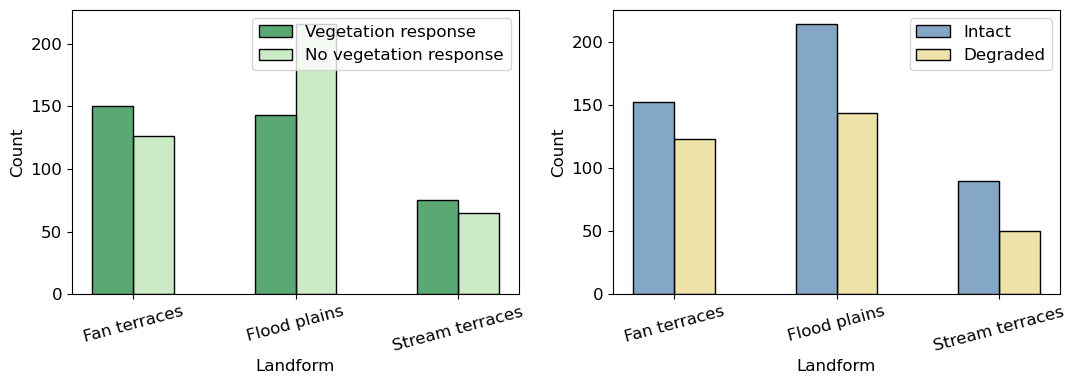

In [66]:
plot_df = data.copy()

plot_df["Intact"] = pd.Categorical(
    np.where(plot_df["Intact"].astype(bool), "Intact", "Degraded"),
    categories=["Intact", "Degraded"], ordered=True
)

palette_eff = eff_colors
palette_int = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stability
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Effective",
    multiple="dodge", shrink=0.5, stat="count",
    palette=palette_eff, hue_order=eff_order,
    ax=axes[0], legend=True
)

# Intactness
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Intact",
    hue_order=["Intact", "Degraded"], palette=palette_int,
    multiple="dodge", shrink=0.5, stat="count",
    ax=axes[1], legend=True
)

# Title/position legends the seaborn way (no manual ax.legend() call)
try:
    sns.move_legend(axes[0], "upper right", title="", frameon=True)
    sns.move_legend(axes[1], "upper right", title="", frameon=True)
except Exception:
    # Fallback for older seaborn: retitle existing legends if present
    if axes[0].legend_ is not None: axes[0].legend_.set_title("Stability")
    if axes[1].legend_ is not None: axes[1].legend_.set_title("Intactness")

for ax in axes:
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()



## Hypothesis tests

In [67]:
from scipy.stats import fisher_exact, chi2_contingency  # kept for local use
from plotting import (
    width,
    _sig_stars, _two_cat_metrics,
    _draw_two_cat_panel, _draw_multi_cat_panel,
)

# Slope labels (referenced by later cells)
shallow_lbl = 'Shallow (≤ 2%)'
steep_lbl   = 'Steep (> 2%)'


Updated → ../latex/figure_report_outcomes.tex  (fig4)


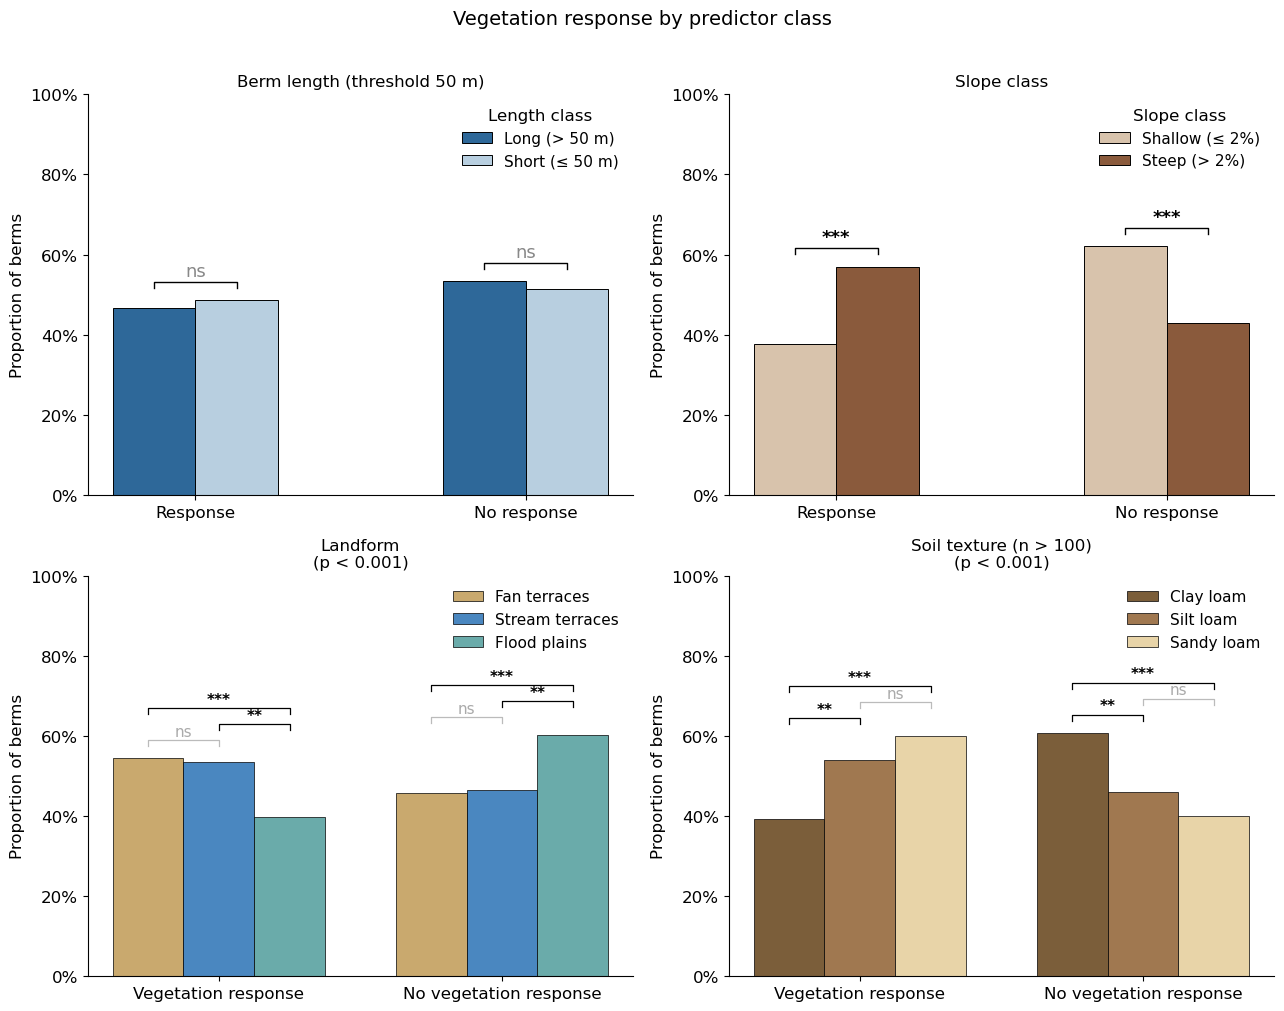

In [68]:
from pathlib import Path
from scipy.stats import chi2_contingency, fisher_exact
from itertools import combinations as _combinations

_w = 0.25   # bar half-width for this cell

# Length labels (matching len_bin values and LENGTH_COLORS keys)
long_lbl  = "Long (> 50 m)"
short_lbl = "Short (≤ 50 m)"

thr = 50   # length threshold in metres (matches Berm_Length_Class)

# Slope labels (matching Slope_Class values created earlier)
shallow_lbl = "Shallow (≤ 2%)"
steep_lbl   = "Steep (> 2%)"

# ── Helpers (vegetation-response versions) ────────────────────────────────

def _eff_two_cat_metrics(df_sub, group_col, cat_a, cat_b):
    """Fisher exact for vegetation response rate between two categories."""
    d = df_sub.dropna(subset=[group_col, "Effective"]).copy()
    n_a = (d[group_col] == cat_a).sum()
    n_b = (d[group_col] == cat_b).sum()
    rows = {}
    for metric, pos_fn in [(LBL_EFFECTIVE,   lambda x: x["Effective"] == LBL_EFFECTIVE),
                            (LBL_INEFFECTIVE, lambda x: x["Effective"] == LBL_INEFFECTIVE)]:
        mask = pos_fn(d)
        c_a  = mask[d[group_col] == cat_a].sum()
        c_b  = mask[d[group_col] == cat_b].sum()
        p_a, p_b = c_a / n_a, c_b / n_b
        direction = "greater" if p_a >= p_b else "less"
        _, p_val = fisher_exact([[c_a, n_a - c_a], [c_b, n_b - c_b]], alternative=direction)
        rows[metric] = {cat_a: p_a, cat_b: p_b, "sig": _sig_stars(p_val)}
    return pd.DataFrame(rows).T

def _draw_eff_two_cat_panel(ax, m, cat_a, cat_b, colors, legend_title, title):
    outcomes = [LBL_EFFECTIVE, LBL_INEFFECTIVE]
    short    = ["Response", "No response"]
    x = np.arange(2)
    for cat, offset in [(cat_a, -_w/2), (cat_b, _w/2)]:
        vals = [m.loc[o, cat] for o in outcomes]
        ax.bar(x + offset, vals, _w, label=cat, color=colors[cat],
               edgecolor="black", linewidth=0.7)
    for i, o in enumerate(outcomes):
        sig = m.loc[o, "sig"]
        top = max(m.loc[o, cat_a], m.loc[o, cat_b]) + 0.03
        bh  = 0.015
        ax.plot([x[i]-_w/2, x[i]-_w/2, x[i]+_w/2, x[i]+_w/2],
                [top, top+bh, top+bh, top], lw=1, color="black")
        col = "black" if sig != "ns" else "#888888"
        ax.text(x[i], top+bh+0.005, sig, ha="center", va="bottom",
                fontsize=13, color=col, fontweight="bold" if sig != "ns" else "normal")
    ax.set_xticks(x)
    ax.set_xticklabels(short)
    ax.set_ylabel("Proportion of berms")
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(title=legend_title, frameon=False, fontsize=11, loc="upper right")
    sns.despine(ax=ax)

def _draw_eff_multi_cat_panel(ax, df_sub, group_col, cat_order, cat_colors, title, pairwise=False):
    """Grouped bars: Response / No response x-axis, one bar per category."""
    d = df_sub.dropna(subset=[group_col, "Effective"]).copy()
    cats   = [c for c in cat_order if c in d[group_col].unique()]
    n_cats = len(cats)
    bar_w  = _w
    _mc_w  = n_cats * bar_w
    offsets = np.linspace(-_mc_w/2 + bar_w/2, _mc_w/2 - bar_w/2, n_cats)
    outcomes = [LBL_EFFECTIVE, LBL_INEFFECTIVE]
    short    = ["Vegetation response", "No vegetation response"]
    x = np.arange(2)

    bars_data = {}
    ns_cat = {}
    for cat in cats:
        sub  = d[d[group_col] == cat]
        n    = len(sub)
        ns_cat[cat] = n
        bars_data[cat] = {
            LBL_EFFECTIVE:   (sub["Effective"] == LBL_EFFECTIVE).sum() / n,
            LBL_INEFFECTIVE: (sub["Effective"] == LBL_INEFFECTIVE).sum() / n,
        }

    # overall chi-sq for title
    ct_chi = pd.crosstab(d[group_col], d["Effective"]).reindex(cats).dropna()
    _, p_chi, *_ = chi2_contingency(ct_chi)
    p_str = f"p = {p_chi:.3g}" if p_chi >= 0.001 else "p < 0.001"

    for ci, (cat, offset) in enumerate(zip(cats, offsets)):
        for oi, outcome in enumerate(outcomes):
            ax.bar(x[oi] + offset, bars_data[cat][outcome], bar_w,
                   color=cat_colors.get(cat, "#aaaaaa"), edgecolor="black", linewidth=0.5,
                   label=cat if oi == 0 else "_nolegend_")

    bh = 0.015

    if pairwise:
        pair_list = list(_combinations(range(n_cats), 2))
        pair_list.sort(key=lambda p: abs(offsets[p[1]] - offsets[p[0]]))
        global_y_max = 0
        for oi, outcome in enumerate(outcomes):
            current_top = max(bars_data[cat][outcome] for cat in cats) + 0.03
            for ci, cj in pair_list:
                ca, cb = cats[ci], cats[cj]
                na, nb = ns_cat[ca], ns_cat[cb]
                ka = (d[d[group_col]==ca]["Effective"] == outcome).sum()
                kb = (d[d[group_col]==cb]["Effective"] == outcome).sum()
                p_a, p_b = ka/na, kb/nb
                direction = "greater" if p_a >= p_b else "less"
                _, p_pair = fisher_exact([[ka, na-ka], [kb, nb-kb]], alternative=direction)
                sig = _sig_stars(p_pair)
                x_left  = x[oi] + offsets[ci]
                x_right = x[oi] + offsets[cj]
                y_base  = max(bars_data[ca][outcome], bars_data[cb][outcome])
                y_start = max(y_base + 0.02, current_top)
                ax.plot([x_left, x_left, x_right, x_right],
                        [y_start, y_start+bh, y_start+bh, y_start],
                        lw=0.9, color="black" if sig != "ns" else "#bbbbbb")
                col = "black" if sig != "ns" else "#aaaaaa"
                ax.text((x_left+x_right)/2, y_start+bh+0.003, sig,
                        ha="center", va="bottom", fontsize=11, color=col,
                        fontweight="bold" if sig != "ns" else "normal")
                current_top = y_start + bh + 0.025
            global_y_max = max(global_y_max, current_top)
        y_max = global_y_max + 0.04
    else:
        sig_overall = _sig_stars(p_chi)
        for oi in range(2):
            vals = [bars_data[cat][outcomes[oi]] for cat in cats]
            top  = max(vals) + 0.03
            ax.plot([x[oi]-_mc_w/2, x[oi]-_mc_w/2, x[oi]+_mc_w/2, x[oi]+_mc_w/2],
                    [top, top+bh, top+bh, top], lw=1, color="black")
            col = "black" if sig_overall != "ns" else "#888888"
            ax.text(x[oi], top+bh+0.005, sig_overall, ha="center", va="bottom",
                    fontsize=13, color=col, fontweight="bold" if sig_overall != "ns" else "normal")
        y_max = max(max(bars_data[cat][o] for cat in cats) for o in outcomes) + 0.12

    ax.set_xticks(x)
    ax.set_xticklabels(short)
    ax.set_ylabel("Proportion of berms")
    ax.set_title(f"{title}\n({p_str})", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.legend(frameon=False, fontsize=11, loc="upper right")
    sns.despine(ax=ax)

# ── Two-category vegetation-response metrics ───────────────────────────────
eff_len_m   = _eff_two_cat_metrics(data, "Berm_Length_Class", long_lbl, short_lbl)
eff_slope_m = _eff_two_cat_metrics(data, "Slope_Class", shallow_lbl, steep_lbl)

# Use canonical colours from constants (keyed on the canonical 50m labels)
EFF_COLORS_LEN   = {long_lbl:  LENGTH_COLORS["Long (> 50 m)"],
                    short_lbl: LENGTH_COLORS["Short (≤ 50 m)"]}
EFF_COLORS_SLOPE = {shallow_lbl: SLOPE_COLORS["Shallow (≤ 2%)"],
                    steep_lbl:   SLOPE_COLORS["Steep (> 2%)"]}

# ── Texture colours — use canonical palette from constants ──
tex_counts2    = data["Texture"].value_counts()
tex_valid2     = tex_counts2[tex_counts2 > 100].index
tex_order_eff  = [t for t in texture_order if t in tex_valid2]
tex_colors_eff = {t: TEXTURE_COLORS.get(t, "#aaaaaa") for t in tex_order_eff}

# ── 2×2 figure ────────────────────────────────────────────────────────────
plt.rcParams.update({"font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12,
                     "xtick.labelsize": 12, "ytick.labelsize": 12})
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

_draw_eff_two_cat_panel(axes[0, 0], eff_len_m, long_lbl, short_lbl,
    EFF_COLORS_LEN, "Length class",
    f"Berm length (threshold {thr} m)")

_draw_eff_two_cat_panel(axes[0, 1], eff_slope_m, shallow_lbl, steep_lbl,
    EFF_COLORS_SLOPE, "Slope class",
    "Slope class")

_draw_eff_multi_cat_panel(axes[1, 0], data, "Landform",
    lf_order, LF_COLORS,
    "Landform", pairwise=True)

_draw_eff_multi_cat_panel(axes[1, 1], data, "Texture",
    tex_order_eff, tex_colors_eff,
    "Soil texture (n > 100)", pairwise=True)

plt.suptitle("Vegetation response by predictor class", fontsize=14, y=1.01)
plt.tight_layout()

# ── Save and register as Paper 1 Figure 4 ─────────────────────────────────
_out = Path("../figures/outcomes/fig4_vegetation_response.png")
_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out, dpi=300, bbox_inches="tight")

register_outcomes_figure(
    "FIG_4",
    label="fig4",
    file_name=_out.name,
    stats_text=(
        "Two-category panels (length, slope) use a one-sided Fisher's exact test; "
        "multi-category panels (landform, texture) use pairwise Fisher's exact tests "
        "with the overall chi-squared p-value shown in the panel title."
    ),
    interpretation_text=(
        "Vegetation response is significantly associated with slope class (p < 0.001), "
        "landform (p < 0.001), and soil texture (p < 0.001), but not with berm "
        "length alone. Steep-slope berms and flood-plain berms show the highest rates "
        "of vegetation response."
    ),
)

plt.show()


In [69]:
data.groupby("Effective")[['FA_30_max', 'FA_60_max']].median()/1000
# tend to have longer flow accumulation i ineffective berms

,FA_30_max,FA_60_max
Effective,,
No vegetation response,2.562,9.1800
Vegetation response,1.667,3.1595


In [70]:
data.groupby("Intact")[['FA_30_max', 'FA_60_max']].median()/1000
# tend to have longer flow accumulation in ineffective berms

,FA_30_max,FA_60_max
Intact,,
False,4.5480,9.629
True,1.0595,2.708


## Exploratory plots

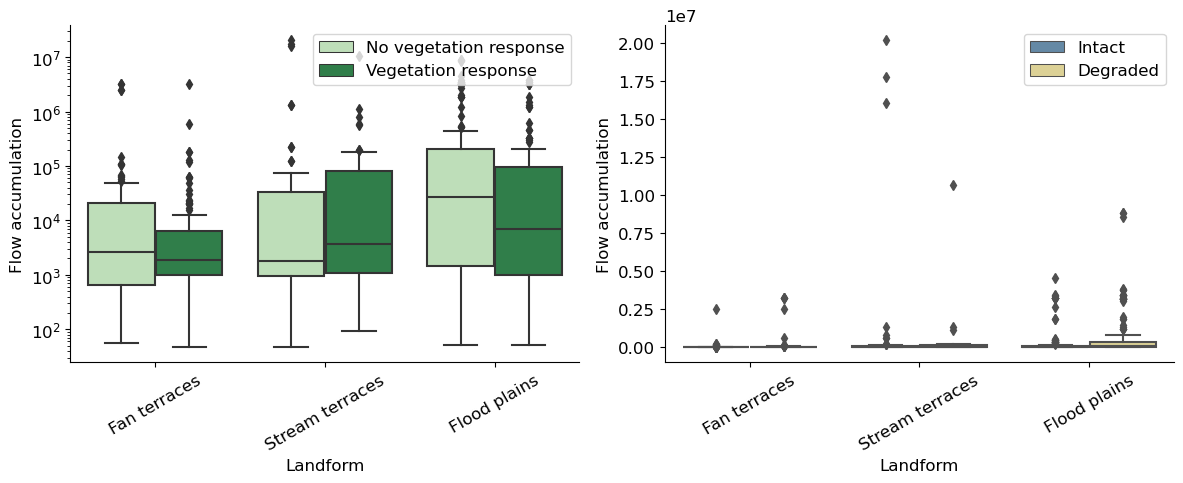

In [71]:
FA_COL = "FA_60_max"   # ← change to "FA_30_max" to switch metric

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

balanced_data = data.query("Type == 'Berm'").copy() if "Type" in data.columns else data.copy()

# consistent Landform order across panels
landform_order = ["Fan terraces", "Stream terraces", "Flood plains"]

# helper: remove top+right spines, add bar outlines, log y
def style_bar_ax(ax):
    sns.despine(ax=ax, top=True, right=True)
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(0.8)
    ax.set_yscale("log")

    # make sure the bottom is > 0 on log scale
    heights = [p.get_height() for p in ax.patches if np.isfinite(p.get_height()) and p.get_height() > 0]
    if heights:
        ax.set_ylim(bottom=min(heights) / 2)

eps = 1e-6  # only used if any medians are 0 (log scale needs >0)

# --- Panel 1: FA_COL by Landform, hue=Effective ---
eff_med = (
    balanced_data.groupby(["Landform", "Effective"], dropna=False)[[FA_COL]]
    .median()
    .reset_index()
)
eff_med[FA_COL] = eff_med[FA_COL].clip(lower=eps)

sns.boxplot(
    data=balanced_data, x="Landform", y=FA_COL, hue="Effective",
    order=landform_order,
    palette=palette_eff,
    ax=axes[0],
)
axes[0].set_xlabel("Landform")
axes[0].set_ylabel(f"Flow accumulation")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_yscale('log')
sns.despine(ax=axes[0], top=True, right=True)

# --- Panel 2: FA_COL by Landform, hue=Condition/Intact ---
if "Condition" in balanced_data.columns:
    cond_col = "Condition"
    bd2 = balanced_data

cond_med = (
    bd2.groupby(["Landform", cond_col], dropna=False)[[FA_COL]]
    .median()
    .reset_index()
    .rename(columns={cond_col: "Condition"})
)
cond_med[FA_COL] = cond_med[FA_COL].clip(lower=eps)

sns.boxplot(
    data=balanced_data, x="Landform", y=FA_COL, hue="Condition",
    order=landform_order,
    palette=palette_int,
    ax=axes[1],
)
axes[1].set_xlabel("Landform")
axes[1].set_ylabel(f"Flow accumulation")
axes[1].tick_params(axis="x", rotation=30)
sns.despine(ax=axes[1], top=True, right=True)

# --- consistent legend placement ---
remove_legend_titles(axes)
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor(None)
        leg._loc = 1            # upper right
        leg.set_alignment("left")

plt.tight_layout()
fig.savefig("../figures/scratch/fa_boxplots_by_landform.png", dpi=300, bbox_inches="tight")

plt.show()

In [72]:
from registry import (
    upsert_latex_figentry,
    register_outcomes_figure,
    register_failure_mechanisms_figure,
    update_figure_registry,
)


Saved → ../figures/outcomes/SI_fig1_fa30_pointplot_by_landform.png
Updated → ../latex/figure_report_outcomes.tex  (Supplementary Figure 1)


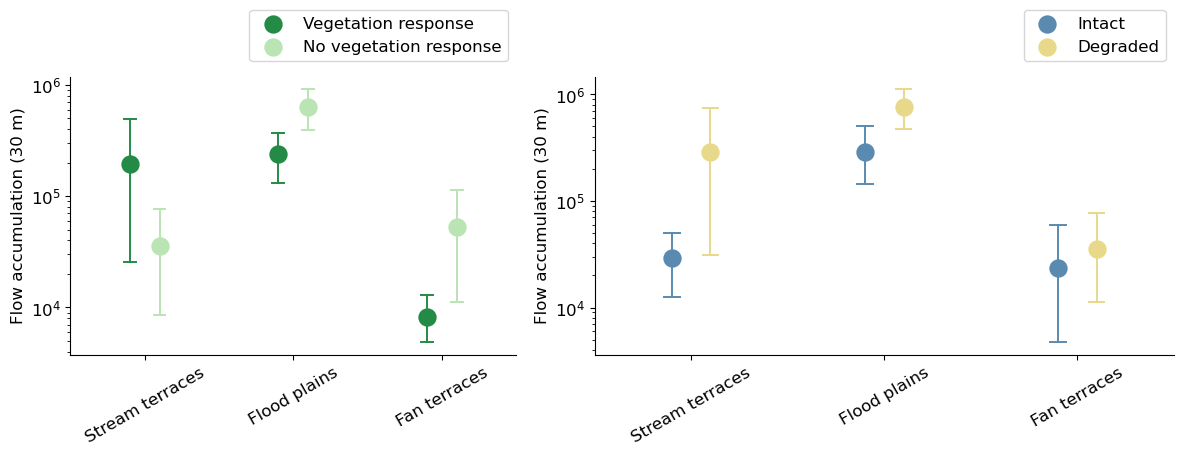

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [1, 1.3]})
axes = axes.ravel()

sns.pointplot(data, x="Landform", y="FA_30_max", hue="Effective", ax=axes[0],
              dodge=0.2, capsize=0.08, errwidth=1.4, scale=1.5, join=False,
              palette=palette_eff, hue_order=eff_order)

sns.pointplot(data, x="Landform", y="FA_30_max", hue="Condition", ax=axes[1],
              dodge=0.2, capsize=0.08, errwidth=1.4, scale=1.5, join=False,
              palette=palette_int, hue_order=["Intact", "Degraded"])

for ax in axes:
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Flow accumulation (30 m)")
axes[1].set_ylabel("Flow accumulation (30 m)")

# --- consistent legend placement (above plot area, no title) ---
remove_legend_titles(axes)
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.0, 1.27))
        leg._loc = 1            # upper right
        leg.set_alignment("left")

plt.tight_layout()

# ── save as Paper 1 SI Figure 1 ──
out_path = Path("../figures/outcomes/SI_fig1_fa30_pointplot_by_landform.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved → {out_path}")

# ── upsert into Paper 1 LaTeX ──
register_outcomes_figure(
    tag="SI_FIG_1",
    label="Supplementary Figure 1",
    file_name=r"SI\_fig1\_fa30\_pointplot\_by\_landform.png",
    stats_text=(
        "Point plots show mean $\\pm$ 95\\% CI of 30\\,m flow accumulation "
        "(log scale) by landform, grouped by vegetation response (Panel A) "
        "and structural condition (Panel B)."
    ),
    interpretation_text=(
        "Flood-plain berms experience the highest contributing flow "
        "accumulation regardless of outcome, while fan-terrace berms "
        "receive the least. Within each landform, effective berms "
        "tend to have similar or higher flow accumulation than "
        "ineffective berms, and degraded berms tend toward higher "
        "values than intact berms, consistent with greater hydraulic "
        "stress on degraded structures."
    ),
)
plt.show()

Saved → ../figures/outcomes/SI_fig3_countplots_by_outcome_and_landform.png
Updated → ../latex/figure_report_outcomes.tex  (Supplementary Figure 3)


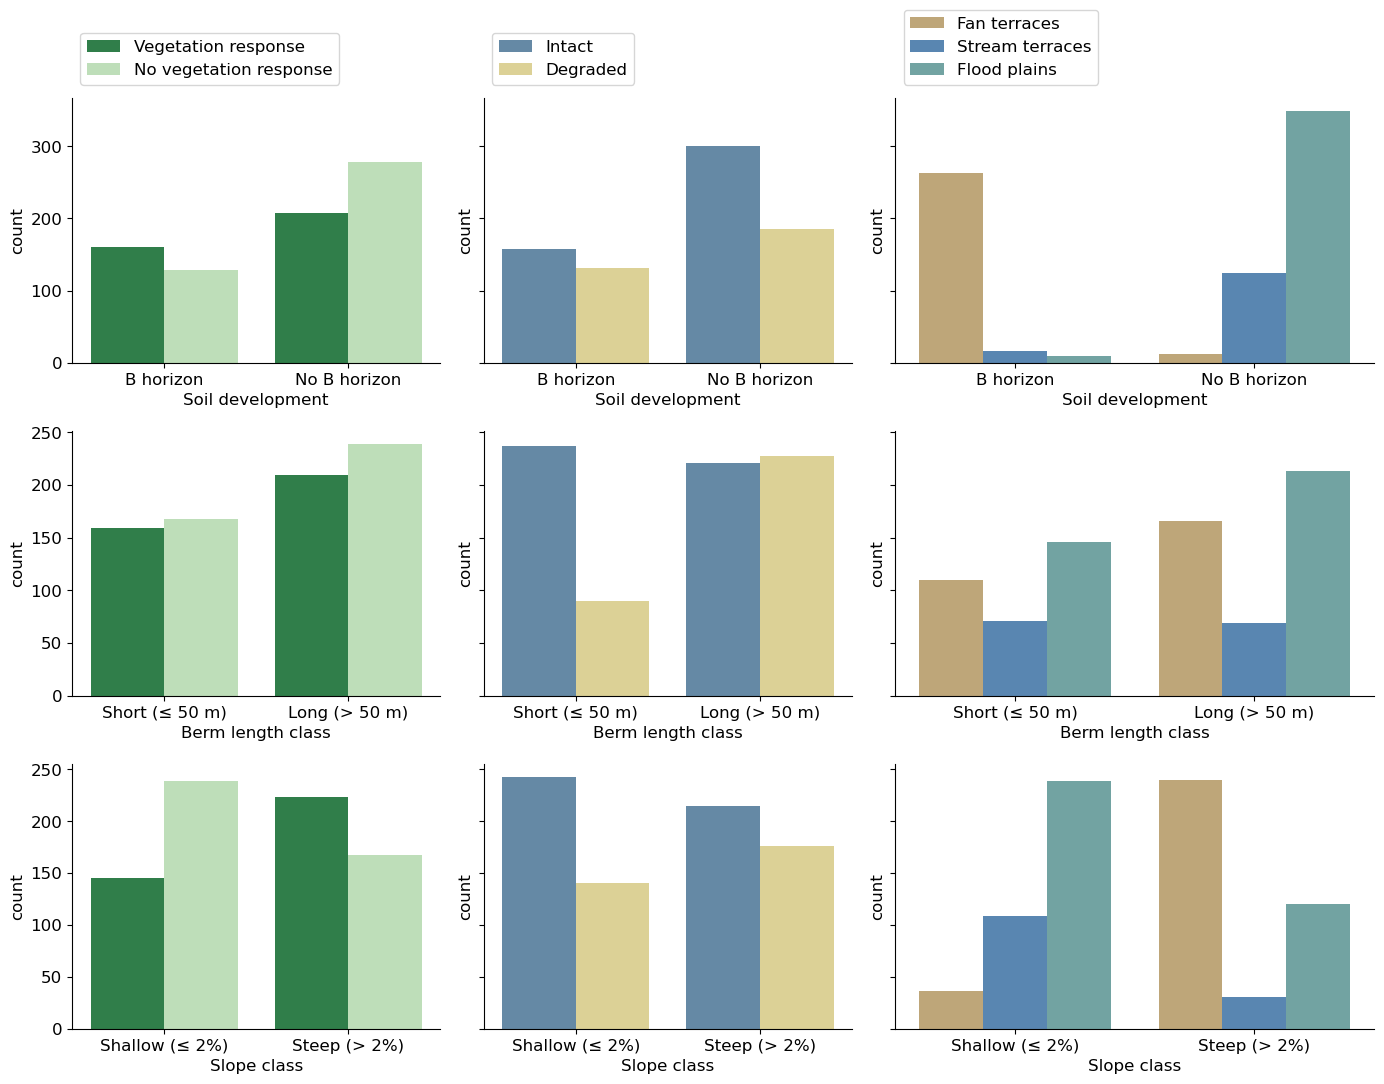

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharey="row",
                         gridspec_kw={"width_ratios": [1, 1, 1.3]})

# ── Row 0: Soil Development ──
soil_order = ["B horizon", "No B horizon"]
sns.countplot(data=data, x="Soil_Development", hue="Effective", ax=axes[0, 0],
              palette=palette_eff, hue_order=eff_order, order=soil_order)
sns.countplot(data=data, x="Soil_Development", hue="Condition", ax=axes[0, 1],
              palette=palette_int, hue_order=["Intact", "Degraded"], order=soil_order)
sns.countplot(data=data, x="Soil_Development", hue="Landform", ax=axes[0, 2],
              palette=LF_COLORS, hue_order=lf_order, order=soil_order)
for ax in axes[0]:
    ax.set_xlabel("Soil development")

# ── Row 1: Berm Length Class ──
sns.countplot(data=data, x="Berm_Length_Class", hue="Effective", ax=axes[1, 0],
              palette=palette_eff, hue_order=eff_order, order=length_order)
sns.countplot(data=data, x="Berm_Length_Class", hue="Condition", ax=axes[1, 1],
              palette=palette_int, hue_order=["Intact", "Degraded"], order=length_order)
sns.countplot(data=data, x="Berm_Length_Class", hue="Landform", ax=axes[1, 2],
              palette=LF_COLORS, hue_order=lf_order, order=length_order)
for ax in axes[1]:
    ax.set_xlabel("Berm length class")

# ── Row 2: Slope Class ──
sns.countplot(data=data, x="Slope_Class", hue="Effective", ax=axes[2, 0],
              palette=palette_eff, hue_order=eff_order, order=slope_order)
sns.countplot(data=data, x="Slope_Class", hue="Condition", ax=axes[2, 1],
              palette=palette_int, hue_order=["Intact", "Degraded"], order=slope_order)
sns.countplot(data=data, x="Slope_Class", hue="Landform", ax=axes[2, 2],
              palette=LF_COLORS, hue_order=lf_order, order=slope_order)
for ax in axes[2]:
    ax.set_xlabel("Slope class")

# ── One legend per column (top row only), remove all others ──
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        sns.despine(ax=ax)
        if row == 0:
            # keep legend on top row, upper-left corner, remove title
            leg = ax.get_legend()
            if leg:
                leg.set_title("")
                leg.set_bbox_to_anchor((0.0, 1.02), transform=ax.transAxes)
                leg._loc = 3            # lower left (anchored above axes)
        else:
            ax.get_legend().remove()

fig.tight_layout()

# ── save as Paper 1 SI Figure 3 ──
out_path = Path("../figures/outcomes/SI_fig3_countplots_by_outcome_and_landform.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved → {out_path}")

register_outcomes_figure(
    tag="SI_FIG_3",
    label="Supplementary Figure 3",
    file_name=r"SI\_fig3\_countplots\_by\_outcome\_and\_landform.png",
    stats_text=(
        "3$\\times$3 panel of count plots. Rows: soil development (B horizon vs.\\ none), "
        "berm length class (short vs.\\ long), slope class (shallow vs.\\ steep). "
        "Columns: vegetation response, structural condition, landform."
    ),
    interpretation_text=(
        "Fan-terrace berms are overwhelmingly found in B-horizon soils, whereas "
        "stream-terrace and flood-plain berms dominate in soils without a B horizon. "
        "Berm length and slope class are more evenly distributed across outcomes, "
        "though short berms are disproportionately intact and steep-slope berms "
        "show a higher proportion of vegetation response."
    ),
)
plt.show()

In [75]:
data.sort_values("Landform")['Landform'].unique()

array(['Fan terraces', 'Flood plains', 'Stream terraces'], dtype=object)

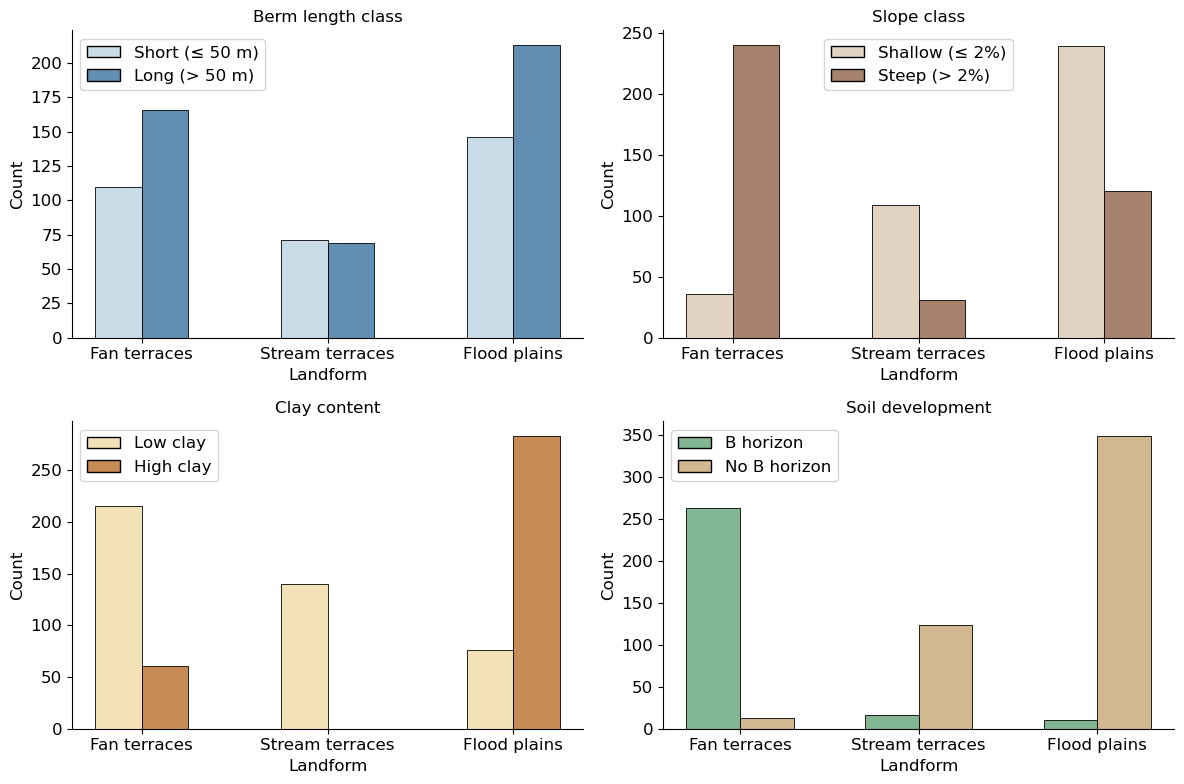

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.ravel()

# Enforce canonical landform order (from cell 17) via Categorical
_lf_sort = data.copy()
_lf_sort["Landform"] = pd.Categorical(_lf_sort["Landform"], categories=lf_order, ordered=True)
_lf_sort = _lf_sort.sort_values("Landform")

# Map boolean High_Clay to canonical labels for palette
_lf_sort["High_Clay_Label"] = np.where(_lf_sort["High_Clay"], "High clay", "Low clay")

sns.histplot(data=_lf_sort, x="Landform",
             hue="Berm_Length_Class", ax=axes_flat[0], stat="count",
             shrink=0.5, multiple="dodge", palette=LENGTH_COLORS,
             hue_order=length_order)
axes_flat[0].set_title("Berm length class")

sns.histplot(data=_lf_sort, x="Landform",
             hue="Slope_Class", ax=axes_flat[1], stat="count",
             shrink=0.5, multiple="dodge", palette=SLOPE_COLORS,
             hue_order=slope_order)
axes_flat[1].set_title("Slope class")

sns.histplot(data=_lf_sort, x="Landform",
             hue="High_Clay_Label", ax=axes_flat[2], stat="count",
             shrink=0.5, multiple="dodge", palette=CLAY_COLORS,
             hue_order=clay_order)
axes_flat[2].set_title("Clay content")

sns.histplot(data=_lf_sort, x="Landform",
             hue="Soil_Development", ax=axes_flat[3], stat="count",
             shrink=0.6, multiple="dodge", palette=SOILDEV_COLORS,
             hue_order=soildev_order)
axes_flat[3].set_title("Soil development")

# ── Styling: despine, edge colours, axis labels ──
for ax in axes_flat:
    sns.despine(ax=ax)
    for p in ax.patches:
        p.set_edgecolor("black")
        p.set_linewidth(0.6)
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")

remove_legend_titles(axes_flat)
fig.tight_layout()



### Significance tests

In [77]:
from analysis import (
    _auto_positive, chi2_with_cramers_v, _two_prop_z, _bh_adjust,
    pairwise_by_group, analyze_outcome,
)


In [78]:
out_eff = analyze_outcome(data, group_col="Landform", outcome_col="Effective", positive=None, fdr_alpha=0.05)
out_int = analyze_outcome(data, group_col="Landform", outcome_col="Intact",    positive=None, fdr_alpha=0.05)

def _print_pairwise(pairwise_df, label):
    print(f"\nPairwise comparisons — {label}:")
    print(pairwise_df
          .assign(prop_a=lambda d: d["prop_a"].round(3),
                  prop_b=lambda d: d["prop_b"].round(3),
                  diff_a_minus_b=lambda d: d["diff_a_minus_b"].round(3),
                  p_raw=lambda d: d["p_raw"].round(4),
                  q_fdr=lambda d: d["q_fdr"].round(4))
          .reset_index(drop=True)
          .to_string())

# ── Print results: Effectiveness ──
print("\n=== Stability (Effective) vs Landform ===")
print("Global χ² p-value:", f"{out_eff['global']['p_value']:.3g}",
      "| Cramér's V:", f"{out_eff['global']['cramers_v']:.3f}")
print("\nProportion Effective by Landform:")
print(out_eff["proportions"].round(3))
_print_pairwise(out_eff["pairwise"], "Effective")

# ── Print results: Intactness ──
print("\n=== Intactness (Intact) vs Landform ===")
print("Global χ² p-value:", f"{out_int['global']['p_value']:.3g}",
      "| Cramér's V:", f"{out_int['global']['cramers_v']:.3f}")
print("\nProportion Intact by Landform:")
print(out_int["proportions"].round(3))
_print_pairwise(out_int["pairwise"], "Intact")
# TODO: update effective to vegetation response. add figure to paper 1


=== Stability (Effective) vs Landform ===
Global χ² p-value: 0.000385 | Cramér's V: 0.142

Proportion Effective by Landform:
Landform
Flood plains       0.602
Stream terraces    0.464
Fan terraces       0.457
Name: proportion, dtype: float64

Pairwise comparisons — Effective:
        group_a          group_b  prop_a  prop_b  diff_a_minus_b test   p_raw   q_fdr  significant
0  Flood plains     Fan terraces   0.602   0.457           0.145    z  0.0003  0.0008         True
1  Flood plains  Stream terraces   0.602   0.464           0.137    z  0.0054  0.0082         True
2  Fan terraces  Stream terraces   0.457   0.464          -0.008    z  0.8806  0.8806        False

=== Intactness (Intact) vs Landform ===
Global χ² p-value: 0.204 | Cramér's V: 0.064

Proportion Intact by Landform:
Landform
Stream terraces    0.643
Flood plains       0.599
Fan terraces       0.554
Name: proportion, dtype: float64

Pairwise comparisons — Intact:
        group_a          group_b  prop_a  prop_b  diff_a_mi

In [79]:
from plotting import _draw_outcome_panel


### Distinguisihing 

In [80]:
len(data) - data['Intact'].sum()

317

In [81]:
df = data.copy()
df["Condition"] = np.where(df["Intact"], "Intact", "Degraded")  # degraded = Intact==False

# counts of Effective / Ineffective
ct = pd.crosstab([df["Landform"], df["Condition"]], df["Effective"])
ct = ct.reindex(columns=eff_order, fill_value=0)

# add totals + rate
ct["N"] = ct.sum(axis=1)
ct["p_effective"] = ct[LBL_EFFECTIVE] / ct["N"]

# wide view: one row per landform, separate columns for Intact vs Degraded
wide = ct.reset_index().pivot(index="Landform", columns="Condition",
                              values=[LBL_EFFECTIVE, LBL_INEFFECTIVE, "N", "p_effective"])
wide.columns = [f"{metric}_{cond.lower()}" for metric, cond in wide.columns]

eff_intact   = f"p_effective_intact"
eff_degraded = f"p_effective_degraded"
wide["Δp_effective (degraded-intact)"] = wide[eff_degraded] - wide[eff_intact]
wide["RR_effective (degraded/intact)"] = wide[eff_degraded] / wide[eff_intact]

wide.sort_values("Δp_effective (degraded-intact)", ascending=False)
# need some sort of significance test

,Vegetation response_degraded,Vegetation response_intact,No vegetation response_degraded,No vegetation response_intact,N_degraded,N_intact,p_effective_degraded,p_effective_intact,Δp_effective (degraded-intact),RR_effective (degraded/intact)
Landform,,,,,,,,,,
Flood plains,60.0,83.0,84.0,132.0,144.0,215.0,0.416667,0.386047,0.030620,1.079317
Fan terraces,68.0,82.0,55.0,71.0,123.0,153.0,0.552846,0.535948,0.016898,1.031529
Stream terraces,26.0,49.0,24.0,41.0,50.0,90.0,0.520000,0.544444,-0.024444,0.955102


In [82]:
from analysis import (
    _coerce_binary, _collapse_rare_levels, _is_categorical,
    _fit_glm_pseudoR2, _cv_auc, rank_predictors,
)


In [83]:
data[['sandtotal_r', 'surf_sandbg', 'claytotal_r', 'surf_claybg']].corr()

,sandtotal_r,surf_sandbg,claytotal_r,surf_claybg
sandtotal_r,1.000000,0.172848,-0.718145,-0.145694
surf_sandbg,0.172848,1.000000,0.063238,-0.631940
claytotal_r,-0.718145,0.063238,1.000000,0.154840
surf_claybg,-0.145694,-0.631940,0.154840,1.000000


In [84]:
predictors = [
    "Landform",
    "slope_200",    
    "Shape_Leng",
    "ParentMaterial",
    "Soil_Development",
    'FA_30_max',
    'Texture', 

]

In [85]:
df = data.loc[data["Structure_"].isna()].copy()   # or df = data.copy()

# create numeric binary target (Effective column now holds display labels)
df["eff_bin"] = (df["Effective"] == LBL_EFFECTIVE).astype(int)

predictors = [
    "Landform",
    "slope_200",    
    "slope_100",
    "Berm_Length_Class",
    "Shape_Leng",
    "ParentMaterial",
    "Soil_Development",
    "TypicalProfile",
    "sandtotal_r",
     "silttotal_r",
    "claytotal_r",
    "High_Clay",
    "channel_200m",
    "channel_500m",
    "channel_1000m",
    'FA_30_max',
    'Texture', 
]

# Optional: force types for specific predictors
treat_as = {
    "Shape_Leng": "numeric",
    "High_Clay": "categorical",
}

ranked = rank_predictors(df, y="eff_bin", predictors=predictors, treat_as=treat_as)
# ranked.head(15)

# geomorphic, local soil, and 

# identify factors that contribute to berm failure, vegetation response.


In [86]:
ranked_intact = rank_predictors(df, y="Intact", predictors=predictors, treat_as=treat_as)
ranked_intact[["predictor","type","n","cv_auc"]].head(15)

,predictor,type,n,cv_auc
4,Shape_Leng,numeric,743,0.660954
15,FA_30_max,numeric,743,0.660455
7,TypicalProfile,categorical,743,0.629500
3,Berm_Length_Class,categorical,743,0.610299
16,Texture,categorical,743,0.595693
10,claytotal_r,numeric,743,0.578668
8,sandtotal_r,numeric,743,0.562407
11,High_Clay,categorical,743,0.551943
5,ParentMaterial,categorical,621,0.548182
14,channel_1000m,numeric,743,0.547259


In [87]:
from analysis import fit_rf_binary


### Interaction between intactness and effectiveness

In [88]:

# ── Fisher's exact test: effectiveness ~ Intact/Degraded, repeated across grouping variables ──
# For each grouping variable (Landform, ParentMaterial, Soil_Development, Texture),
# test whether the proportion of effective berms differs between Intact and Degraded.

from scipy.stats import fisher_exact

def fisher_by_group(data, group_col, min_n=10):
    """
    For each level of group_col, test whether effectiveness differs
    between Intact (True) and Degraded (False) berms using Fisher's exact test.
    Only tests groups where both Intact and Degraded have >= min_n samples.
    Returns a DataFrame with one row per group level.
    """
    sub = data.dropna(subset=[group_col, "Intact", "effective"]).copy()
    rows = []
    for grp_val, g in sub.groupby(group_col):
        ct = pd.crosstab(g["Intact"], g["effective"]).reindex(
            index=[False, True], columns=[False, True], fill_value=0
        )
        n_deg = int(ct.loc[False].sum())
        n_int = int(ct.loc[True].sum())
        p_deg = ct.loc[False, True] / n_deg if n_deg > 0 else np.nan
        p_int = ct.loc[True, True] / n_int if n_int > 0 else np.nan

        if min(n_deg, n_int) >= min_n:
            table = [
                [ct.loc[False, False], ct.loc[False, True]],
                [ct.loc[True,  False], ct.loc[True,  True]],
            ]
            _, p_val = fisher_exact(table, alternative="two-sided")
        else:
            p_val = np.nan

        rows.append({
            "Variable": group_col,
            "Group": grp_val,
            "n_degraded": n_deg,
            "n_intact": n_int,
            "p_eff_degraded": round(p_deg, 3) if pd.notna(p_deg) else np.nan,
            "p_eff_intact":   round(p_int, 3) if pd.notna(p_int) else np.nan,
            "diff (intact-degraded)": round(p_int - p_deg, 3) if pd.notna(p_int) and pd.notna(p_deg) else np.nan,
            "p_value": round(p_val, 4) if pd.notna(p_val) else np.nan,
            "significant": (p_val < 0.05) if pd.notna(p_val) else False,
        })
    return pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)


# Run across all grouping variables
GROUP_VARS = ["Landform", "ParentMaterial", "Soil_Development", "Texture", "Slope_Class", "Berm_Length_Class"]
all_results = pd.concat(
    [fisher_by_group(data, v, min_n=MIN_N_PER_CATEGORY) for v in GROUP_VARS],
    ignore_index=True,
)

# ── Per-variable tables ──
for var in GROUP_VARS:
    sub_res = all_results[all_results["Variable"] == var].copy()
    print(f"\n{'═'*60}")
    print(f"  {var}  (Fisher's exact, two-sided, min n={MIN_N_PER_CATEGORY} per group)")
    print(f"{'═'*60}")
    display(sub_res.drop(columns="Variable").reset_index(drop=True))

# ── Combined summary: only significant results ──
print("\n\n" + "═"*60)
print("  SUMMARY: Significant differences (p < 0.05)")
print("═"*60)
sig = all_results[all_results["significant"]].reset_index(drop=True)
if len(sig):
    display(sig)
else:
    print("No significant differences found.")

# ── Count of significant results per variable ──
print("\nSignificant pairs per variable:")
print(all_results.groupby("Variable")["significant"].sum().to_string())


NameError: name 'MIN_N_PER_CATEGORY' is not defined

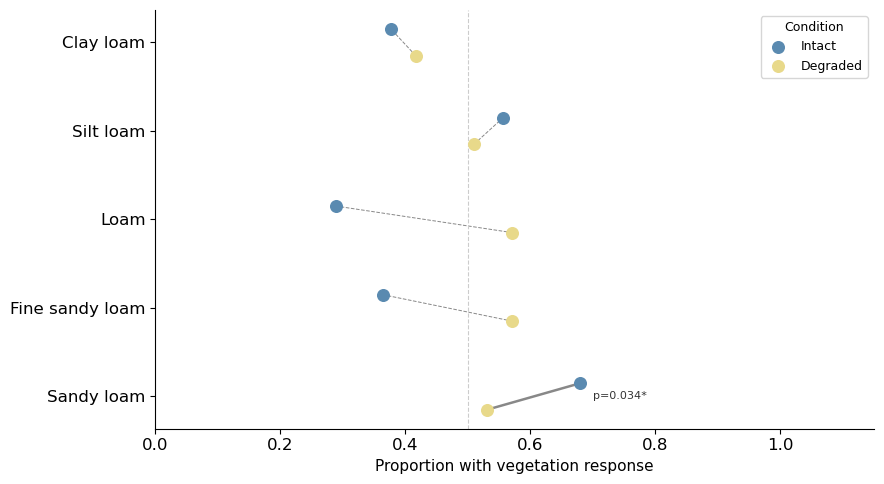

In [ ]:
# ── Visualise: proportion effective by texture and berm condition ─────────────

# Merge p-values into summary for annotation
plot_df = summary.merge(
    results[["Texture", "p_value", "significant_0p05"]],
    on="Texture", how="left"
)

# Keep only textures with at least 50 combined samples
min_n = 50
tex_keep = plot_df.groupby("Texture")["count"].sum()
tex_keep = tex_keep[tex_keep >= min_n].index
plot_df = plot_df[plot_df["Texture"].isin(tex_keep)]

# Use the predefined texture order (finest → coarsest), filtered to what's in plot_df
# Append any textures present in data but not in texture_order (avoids ValueError)
_known = set(texture_order)
tex_order = [t for t in texture_order if t in plot_df["Texture"].values] + \
            [t for t in sorted(plot_df["Texture"].unique()) if t not in _known]

fig, ax = plt.subplots(figsize=(9, 5))

_clr = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}
dodge = {"Intact": -0.15, "Degraded": 0.15}

for grp, color in _clr.items():
    grp_df = plot_df[plot_df["Group"] == grp]
    y_pos = [tex_order.index(t) + dodge[grp] for t in grp_df["Texture"]]
    ax.scatter(grp_df["mean"], y_pos, color=color, s=70, zorder=3, label=grp)

# Connect paired dots with a line; bold + solid if significant
for tex in tex_order:
    row_i = plot_df[(plot_df["Texture"] == tex) & (plot_df["Group"] == "Intact")]
    row_d = plot_df[(plot_df["Texture"] == tex) & (plot_df["Group"] == "Degraded")]
    if row_i.empty or row_d.empty:
        continue
    yi = tex_order.index(tex)
    xi, xd = row_i["mean"].values[0], row_d["mean"].values[0]
    sig = row_i["significant_0p05"].values[0]
    lw = 1.8 if sig else 0.7
    ls = "-" if sig else "--"
    ax.plot([xd, xi], [yi + dodge["Degraded"], yi + dodge["Intact"]],
            color="#888888", linewidth=lw, linestyle=ls, zorder=2)
    if sig:
        p = row_i["p_value"].values[0]
        ax.text(max(xi, xd) + 0.02, yi, f"p={p:.3f}*",
                va="center", fontsize=8, color="#333333")

ax.set_yticks(range(len(tex_order)))
ax.set_yticklabels(tex_order)
ax.set_xlabel(f"Proportion with {LBL_EFFECTIVE.lower()}", fontsize=11)
ax.set_xlim(0, 1.15)
ax.invert_yaxis()
ax.axvline(0.5, color="#cccccc", linewidth=0.8, linestyle="--")
ax.legend(title="Condition", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


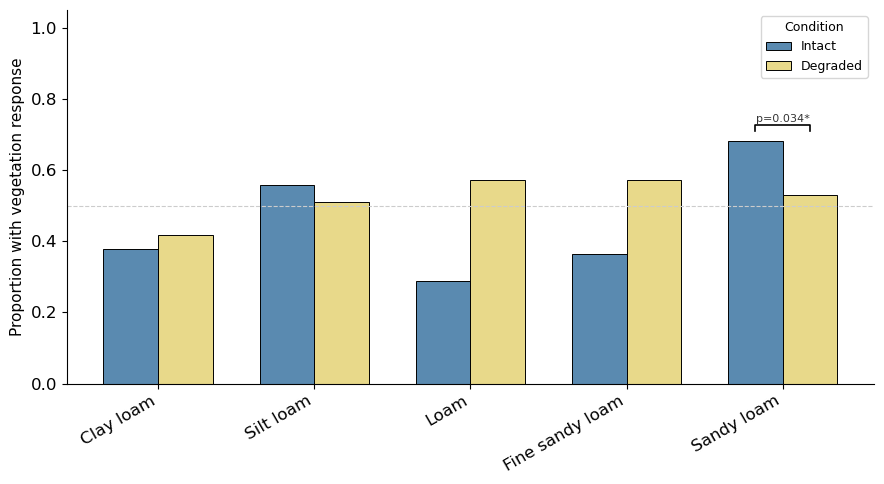

In [ ]:
# ── Barplot version: proportion effective by texture and berm condition ────────
SHOW_COUNTS = False   # True → raw counts; False → proportions

# Reuse the same plot_df built above
_plot_bar = summary.merge(
    results[["Texture", "p_value", "significant_0p05"]],
    on="Texture", how="left"
)

# Keep only textures with at least 50 combined samples
_min_n = 50
_tex_keep = _plot_bar.groupby("Texture")["count"].sum()
_tex_keep = _tex_keep[_tex_keep >= _min_n].index
_plot_bar = _plot_bar[_plot_bar["Texture"].isin(_tex_keep)]

# For count mode, compute effective counts per group
if SHOW_COUNTS:
    _plot_bar = _plot_bar.copy()
    _plot_bar["eff_count"] = (_plot_bar["mean"] * _plot_bar["count"]).round().astype(int)

_known = set(texture_order)
_tex_order = [t for t in texture_order if t in _plot_bar["Texture"].values] + \
             [t for t in sorted(_plot_bar["Texture"].unique()) if t not in _known]

_n_tex = len(_tex_order)
_bar_w = 0.35
_x = np.arange(_n_tex)
_val_col = "eff_count" if SHOW_COUNTS else "mean"

fig, ax = plt.subplots(figsize=(9, 5))

_clr = {"Intact": INTACT_COL, "Degraded": DEGRADED_COL}

for i, (grp, color) in enumerate(_clr.items()):
    _grp_df = _plot_bar[_plot_bar["Group"] == grp].set_index("Texture")
    _vals = [_grp_df.loc[t, _val_col] if t in _grp_df.index else 0 for t in _tex_order]
    _offset = -_bar_w / 2 if i == 0 else _bar_w / 2
    ax.bar(_x + _offset, _vals, _bar_w, label=grp, color=color,
           edgecolor="black", linewidth=0.7)

# Add significance brackets
for j, tex in enumerate(_tex_order):
    _row_i = _plot_bar[(_plot_bar["Texture"] == tex) & (_plot_bar["Group"] == "Intact")]
    _row_d = _plot_bar[(_plot_bar["Texture"] == tex) & (_plot_bar["Group"] == "Degraded")]
    if _row_i.empty or _row_d.empty:
        continue
    _sig = _row_i["significant_0p05"].values[0]
    if _sig:
        _p = _row_i["p_value"].values[0]
        _top = max(_row_i[_val_col].values[0], _row_d[_val_col].values[0])
        _margin = 3 if SHOW_COUNTS else 0.03
        _bh = 2 if SHOW_COUNTS else 0.015
        ax.plot([_x[j] - _bar_w / 2, _x[j] - _bar_w / 2,
                 _x[j] + _bar_w / 2, _x[j] + _bar_w / 2],
                [_top + _margin, _top + _margin + _bh,
                 _top + _margin + _bh, _top + _margin],
                lw=1.2, color="black")
        ax.text(_x[j], _top + _margin + _bh + (_bh * 0.3), f"p={_p:.3f}*",
                ha="center", va="bottom", fontsize=8, color="#333333")

ax.set_xticks(_x)
ax.set_xticklabels(_tex_order, rotation=30, ha="right")

if SHOW_COUNTS:
    ax.set_ylabel(f"Count of berms with {LBL_EFFECTIVE.lower()}", fontsize=11)
else:
    ax.set_ylabel(f"Proportion with {LBL_EFFECTIVE.lower()}", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="#cccccc", linewidth=0.8, linestyle="--")

ax.legend(title="Condition", fontsize=9, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()